# Predicting the Next S&P 500 Session from Headline Sentiment

Notebook 6 of 7. It turns the FinBERT scores of notebook 5 into daily sentiment features and asks whether they predict the direction of the next S&P 500 session's open to close return. The headline model is an XGBoost regressor on sentiment features only, evaluated by an expanding walk-forward so every prediction uses only earlier sessions, and judged by a one-sided exact binomial test against a coin flip: the resume benchmark is 56.3% directional accuracy with p < 0.01.

Every rule below was fixed in the design before any prediction existed. Contrasts (naive rules, returns-only and combined models, a classifier) run on the same sessions so the reader can see what sentiment adds.

## Setup

Imports, constants and helpers: the circular block bootstrap for the accuracy interval and the Pesaran-Timmermann test of directional accuracy. `SMOKE` cuts each tuning study to 3 trials; it is off in this version.

In [1]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from cycler import cycler
from scipy.stats import binomtest, norm

SMOKE = False
SEED = 42
THREADS = 4
TRIALS = 3 if SMOKE else 40
HISTORY, INITIAL, BLOCK = 20, 200, 20
INNER = [(100 + 25 * k, 125 + 25 * k) for k in range(4)]
TARGET_ACCURACY, TARGET_P = 0.563, 0.01
INPUT = Path("/kaggle/input")
OUT = Path("/kaggle/working")
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
COLORS = {"sentiment": "#2a78d6", "sentiment_classifier": "#1baf7a", "sentiment_returns": "#eb6834", "returns_only": "#eda100", "previous_direction": "#898781", "always_up": "#898781"}
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK_2, "text.color": INK, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2, "legend.frameon": False,
    "font.family": "sans-serif", "axes.prop_cycle": cycler(color=SERIES), "axes.titlesize": 11,
})
optuna.logging.set_verbosity(optuna.logging.WARNING)
START = time.time()


def find_file(name):
    hits = sorted(INPUT.rglob(name))
    if not hits:
        raise FileNotFoundError(name)
    return hits[0]


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=110, bbox_inches="tight")
    plt.show()
    plt.close(fig)


def elapsed():
    return f"elapsed {(time.time() - START) / 60:.1f} minutes"


def block_interval(correct, rng, block=10, reps=2000):
    n = len(correct)
    starts = rng.integers(0, n, size=(reps, int(np.ceil(n / block))))
    rows = ((starts[:, :, None] + np.arange(block)) % n).reshape(reps, -1)[:, :n]
    low, high = np.percentile(correct[rows].mean(axis=1), [2.5, 97.5])
    return float(low), float(high)


def pesaran_timmermann(predicted_up, actual_up):
    x, y = np.asarray(predicted_up, dtype=float), np.asarray(actual_up, dtype=float)
    n = len(x)
    p, px, py = np.mean(x == y), x.mean(), y.mean()
    p_star = py * px + (1 - py) * (1 - px)
    var_p = p_star * (1 - p_star) / n
    var_star = (2 * py - 1) ** 2 * px * (1 - px) / n + (2 * px - 1) ** 2 * py * (1 - py) / n + 4 * py * px * (1 - py) * (1 - px) / n ** 2
    if var_p - var_star <= 0:
        return None, None
    stat = (p - p_star) / np.sqrt(var_p - var_star)
    return float(stat), float(norm.sf(stat))


print(f"smoke={SMOKE}, tuning trials per model {TRIALS}")
print(f"xgboost {xgb.__version__}, optuna {optuna.__version__}, pandas {pd.__version__}, numpy {np.__version__}")

smoke=False, tuning trials per model 40
xgboost 3.4.1, optuna 5.0.0, pandas 2.3.3, numpy 2.1.3


**Conclusion.** The smoke switch is off, so each XGBoost model gets its full 40-trial study. XGBoost 3.4.1 and Optuna 5.0.0 come with the image.

## Prices and the target

Reads the ^GSPC history, keeps one row per date, and computes each session's open to close return in percent (the target) and its close to close return (used only by the returns-based contrasts). Every input of the model is public before the opening bell of the session it predicts, so the target starts at the open.

In [2]:
prices = pd.read_csv(find_file("sap500.csv"))
prices["date"] = pd.to_datetime(prices["Date"].astype(str).str[:10])
prices = prices.sort_values("date").drop_duplicates("date").reset_index(drop=True)
prices["oc"] = (prices["Close"] / prices["Open"] - 1) * 100
prices["cc"] = prices["Close"].pct_change() * 100
print(f"price rows {len(prices):,}, {prices['date'].min().date()} to {prices['date'].max().date()}")

price rows 24,805, 1927-12-30 to 2026-10-01


**Conclusion.** The price history runs from 1927-12-30 to 2026-10-01 (24,805 rows); only the stretch covering the headlines is used.

## Mapping headlines to sessions

A headline dated d feeds the first trading session strictly after d, so a Friday evening or weekend headline feeds Monday and nothing dated on a session day feeds that session. A session is used only when its whole window, from the previous session day to the day before it, lies inside the headline range.

In [3]:
scores = pd.read_parquet(find_file("headline_scores.parquet"))
scores["date"] = pd.to_datetime(scores["date"])
dates = prices["date"].to_numpy()
scores["session"] = dates[np.searchsorted(dates, scores["date"].to_numpy(), side="right")]
first, last = scores["date"].min(), scores["date"].max()
calendar = pd.DataFrame({"session": prices["date"], "prev": prices["date"].shift(1)})
covered = calendar.loc[(calendar["prev"] >= first) & (calendar["session"] - pd.Timedelta(days=1) <= last), "session"]
used = scores[scores["session"].isin(covered)].copy()
print(f"headlines scored {len(scores):,}, dated {first.date()} to {last.date()}")
print(f"sessions with a complete headline window: {len(covered)}, {covered.min().date()} to {covered.max().date()}")
print(f"headlines feeding those sessions: {len(used):,}")

headlines scored 32,692, dated 2018-03-20 to 2020-07-18
sessions with a complete headline window: 586, 2018-03-21 to 2020-07-17
headlines feeding those sessions: 32,640


**Conclusion.** All 32,692 scored headlines (2018-03-20 to 2020-07-18) map to a session, and the 586 sessions from 2018-03-21 to 2020-07-17 whose whole window lies inside the headline range draw on 32,640 of them, the counts notebook 1 previewed.

## Session features

The 19 sentiment features of the design, computed per session from its headlines: count and log count; mean positive and negative probability; mean net tone (positive minus negative) and its spread; the shares labelled positive and negative; 3, 5 and 10-session rolling means of net tone and both shares (the current session included); net tone minus its 10-session mean; and the count's z-score against the previous 20 sessions. Rolling windows look only backwards. A session without headlines keeps count 0 and missing values elsewhere, which XGBoost handles natively.

In [4]:
used["net"] = used["p_pos"] - used["p_neg"]
used["is_pos"] = (used["label"] == 2).astype(float)
used["is_neg"] = (used["label"] == 0).astype(float)
grouped = used.groupby("session")
daily = pd.DataFrame({
    "count": grouped.size(),
    "mean_pos": grouped["p_pos"].mean(),
    "mean_neg": grouped["p_neg"].mean(),
    "net_tone": grouped["net"].mean(),
    "net_tone_std": grouped["net"].std(ddof=0),
    "share_pos": grouped["is_pos"].mean(),
    "share_neg": grouped["is_neg"].mean(),
})
frame = pd.DataFrame(index=pd.DatetimeIndex(covered.to_numpy(), name="date")).join(daily)
frame["count"] = frame["count"].fillna(0).astype(int)
frame["log_count"] = np.log1p(frame["count"])
for column in ("net_tone", "share_pos", "share_neg"):
    for k in (3, 5, 10):
        frame[f"{column}_r{k}"] = frame[column].rolling(k, min_periods=1).mean()
frame["net_tone_dev10"] = frame["net_tone"] - frame["net_tone_r10"]
prior = frame["count"].shift(1).rolling(HISTORY, min_periods=HISTORY)
frame["count_z20"] = ((frame["count"] - prior.mean()) / prior.std(ddof=0)).replace([np.inf, -np.inf], np.nan)
SENTIMENT = ["count", "log_count", "mean_pos", "mean_neg", "net_tone", "net_tone_std", "share_pos", "share_neg"] + [f"{c}_r{k}" for c in ("net_tone", "share_pos", "share_neg") for k in (3, 5, 10)] + ["net_tone_dev10", "count_z20"]
print(f"sentiment features: {len(SENTIMENT)}")
print(f"sessions without headlines: {int((frame['count'] == 0).sum())}")
print(frame[SENTIMENT].describe().T[["mean", "std", "min", "max"]].round(4).to_string())

sentiment features: 19
sessions without headlines: 0
                   mean      std      min       max
count           55.6997  18.2867  17.0000  156.0000
log_count        3.9896   0.3102   2.8904    5.0562
mean_pos         0.1897   0.0589   0.0347    0.5230
mean_neg         0.2855   0.0654   0.1062    0.5082
net_tone        -0.0958   0.1043  -0.4246    0.3795
net_tone_std     0.5564   0.0561   0.3713    0.7103
share_pos        0.1769   0.0658   0.0000    0.5294
share_neg        0.2948   0.0778   0.1020    0.5584
net_tone_r3     -0.0959   0.0732  -0.3472    0.1469
net_tone_r5     -0.0959   0.0636  -0.3214    0.1077
net_tone_r10    -0.0958   0.0548  -0.2966    0.0324
share_pos_r3     0.1768   0.0462   0.0426    0.3689
share_pos_r5     0.1767   0.0400   0.0731    0.3430
share_pos_r10    0.1765   0.0332   0.0875    0.2783
share_neg_r3     0.2947   0.0519   0.1450    0.4649
share_neg_r5     0.2946   0.0448   0.1939    0.4479
share_neg_r10    0.2942   0.0387   0.1964    0.4208
net_tone_de

**Conclusion.** All 19 sentiment features are built and no session lacks headlines (56 per session on average, between 17 and 156). Net tone averages -0.096, so a typical session's headlines lean negative; rolling means smooth its session-to-session standard deviation from 0.104 to 0.055 over 10 sessions, and the count z-score runs from -2.6 to 5.6, flagging news-heavy sessions.

## Returns features for the contrasts and the target

The returns-only and combined contrasts use lagged open to close and close to close returns (1 to 5 sessions back) and 5 and 20-session volatility of close to close returns, all known by the previous close. The target, the session's own open to close return, is joined last.

In [5]:
px = prices.set_index("date")
returns = pd.DataFrame(index=px.index)
for k in range(1, 6):
    returns[f"oc_lag{k}"] = px["oc"].shift(k)
    returns[f"cc_lag{k}"] = px["cc"].shift(k)
returns["vol5"] = px["cc"].shift(1).rolling(5).std(ddof=0)
returns["vol20"] = px["cc"].shift(1).rolling(20).std(ddof=0)
RETURNS = list(returns.columns)
frame = frame.join(returns)
frame["target"] = px["oc"].reindex(frame.index)
print(f"returns features: {len(RETURNS)}; missing returns values in the session table: {int(frame[RETURNS].isna().sum().sum())}; missing targets: {int(frame['target'].isna().sum())}")

returns features: 12; missing returns values in the session table: 0; missing targets: 0


**Conclusion.** The 12 returns features and the target are present for every session, with no missing value.

## Walk-forward layout

The first 20 sessions only provide history for the 20-session features. Of the remaining eligible sessions, the first 200 form the initial window; after that the model predicts 20 sessions at a time and is refitted on every earlier eligible session before the next block.

In [6]:
eligible = frame.iloc[HISTORY:].copy()
test = eligible.iloc[INITIAL:]
blocks = int(np.ceil(len(test) / BLOCK))
print(f"eligible sessions {len(eligible)}: {eligible.index.min().date()} to {eligible.index.max().date()}")
print(f"initial window: {INITIAL} sessions, {eligible.index[0].date()} to {eligible.index[INITIAL - 1].date()}")
print(f"walk-forward test: {len(test)} sessions, {test.index.min().date()} to {test.index.max().date()}, in {blocks} blocks of up to {BLOCK}")

eligible sessions 566: 2018-04-19 to 2020-07-17
initial window: 200 sessions, 2018-04-19 to 2019-02-04
walk-forward test: 366 sessions, 2019-02-05 to 2020-07-17, in 19 blocks of up to 20


**Conclusion.** 566 sessions are eligible (2018-04-19 to 2020-07-17). The first 200, to 2019-02-04, form the initial window, and the walk-forward test covers 366 sessions from 2019-02-05 to 2020-07-17 in 19 blocks, the size notebook 1 predicted.

## Tuning each model once, on the initial window

Each XGBoost model gets its own Optuna study (TPE, seed 42, 40 trials) on the initial window only. Inner folds validate on four consecutive blocks of 25 sessions (sessions 101 to 200 of the window), each trained on every earlier session of the window, and the objective is mean inner directional accuracy. The chosen settings are then frozen for every refit. The headline regressor predicts the return in percent and calls a session up when the prediction is at least 0; the classifier contrast predicts up when its probability is at least 0.5.

In [7]:
MODELS = {
    "sentiment": ("regressor", SENTIMENT, "XGBoost regressor, sentiment features (headline)"),
    "sentiment_classifier": ("classifier", SENTIMENT, "XGBoost classifier, sentiment features"),
    "sentiment_returns": ("regressor", SENTIMENT + RETURNS, "XGBoost regressor, sentiment and returns"),
    "returns_only": ("regressor", RETURNS, "XGBoost regressor, lagged returns only"),
}
NAMES = {**{key: value[2] for key, value in MODELS.items()}, "previous_direction": "Previous session direction", "always_up": "Always up"}


def make_model(kind, params):
    settings = {key: params[key] for key in ("n_estimators", "max_depth", "learning_rate", "min_child_weight", "subsample", "colsample_bytree", "reg_lambda")}
    settings.update(tree_method="hist", n_jobs=THREADS, random_state=SEED)
    if kind == "classifier":
        return xgb.XGBClassifier(objective="binary:logistic", **settings)
    return xgb.XGBRegressor(objective=params["objective"], **settings)


def fit(kind, params, rows, features):
    target = (rows["target"] > 0).astype(int) if kind == "classifier" else rows["target"]
    return make_model(kind, params).fit(rows[features], target)


def predict(kind, model, rows, features):
    if kind == "classifier":
        score = model.predict_proba(rows[features])[:, 1]
        return score, score >= 0.5
    score = model.predict(rows[features])
    return score, score >= 0


def suggest(trial, kind):
    params = {
        "max_depth": trial.suggest_int("max_depth", 1, 4),
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_float("min_child_weight", 1.0, 20.0),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    }
    if kind == "regressor":
        params["objective"] = trial.suggest_categorical("objective", ["reg:squarederror", "reg:pseudohubererror"])
    return params


window = eligible.iloc[:INITIAL]
tuned = {}
for name, (kind, features, _) in MODELS.items():
    def objective(trial, kind=kind, features=features):
        params = suggest(trial, kind)
        hits = []
        for lo, hi in INNER:
            model = fit(kind, params, window.iloc[:lo], features)
            _, up = predict(kind, model, window.iloc[lo:hi], features)
            hits.append(np.mean(up == (window["target"].iloc[lo:hi] > 0).to_numpy()))
        return float(np.mean(hits))

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=TRIALS)
    tuned[name] = {"params": dict(study.best_params), "inner_accuracy": study.best_value}
    print(f"{NAMES[name]}: inner accuracy {study.best_value:.4f} with {study.best_params}")
print(elapsed())

XGBoost regressor, sentiment features (headline): inner accuracy 0.5600 with {'max_depth': 3, 'n_estimators': 317, 'learning_rate': 0.011711509955524094, 'min_child_weight': 12.54335218612733, 'subsample': 0.5852620618436457, 'colsample_bytree': 0.5325257964926398, 'reg_lambda': 7.902619549708233, 'objective': 'reg:squarederror'}
XGBoost classifier, sentiment features: inner accuracy 0.5500 with {'max_depth': 4, 'n_estimators': 137, 'learning_rate': 0.052182355444932174, 'min_child_weight': 1.1746892842623917, 'subsample': 0.9405823140734847, 'colsample_bytree': 0.671224427581736, 'reg_lambda': 0.7112415594118229}
XGBoost regressor, sentiment and returns: inner accuracy 0.6000 with {'max_depth': 1, 'n_estimators': 350, 'learning_rate': 0.02944971063736681, 'min_child_weight': 3.4059921149189663, 'subsample': 0.8011671560477487, 'colsample_bytree': 0.6964713484077957, 'reg_lambda': 0.4939713749567098, 'objective': 'reg:squarederror'}
XGBoost regressor, lagged returns only: inner accurac

**Conclusion.** Tuned on the initial window only, the headline regressor chose a shallow, heavily regularised model (depth 3, 317 trees at learning rate 0.012, minimum child weight 12.5, lambda 7.9) at 56% inner accuracy. The contrasts reach 55% (classifier), 60% (sentiment and returns) and 57% (returns only). These inner scores rest on 100 sessions, so differences of a few points are noise; they choose settings, they do not evaluate.

## Walk-forward predictions

For each model, refit on all eligible sessions before each block of 20 and predict the block. The two naive rules need no fitting: always up, and the direction of the previous session's open to close return. No accuracy is computed here; this cell only collects predictions.

In [8]:
predictions, last_models = {}, {}
for name, (kind, features, _) in MODELS.items():
    scores_, ups = [], []
    for start in range(INITIAL, len(eligible), BLOCK):
        model = fit(kind, tuned[name]["params"], eligible.iloc[:start], features)
        score, up = predict(kind, model, eligible.iloc[start:start + BLOCK], features)
        scores_.append(score)
        ups.append(up)
    predictions[name] = {"score": np.concatenate(scores_), "up": np.concatenate(ups)}
    last_models[name] = model
predictions["previous_direction"] = {"score": test["oc_lag1"].to_numpy(), "up": (test["oc_lag1"] > 0).to_numpy()}
predictions["always_up"] = {"score": np.ones(len(test)), "up": np.ones(len(test), dtype=bool)}
for name, pred in predictions.items():
    print(f"{NAMES[name]}: {len(pred['up'])} predictions, share predicted up {pred['up'].mean():.3f}")
print(elapsed())

XGBoost regressor, sentiment features (headline): 366 predictions, share predicted up 0.445
XGBoost classifier, sentiment features: 366 predictions, share predicted up 0.661
XGBoost regressor, sentiment and returns: 366 predictions, share predicted up 0.475
XGBoost regressor, lagged returns only: 366 predictions, share predicted up 0.426
Previous session direction: 366 predictions, share predicted up 0.560
Always up: 366 predictions, share predicted up 1.000
elapsed 1.1 minutes


**Conclusion.** Every model produced 366 walk-forward predictions. The headline regressor calls up on 44.5% of sessions, the classifier on 66.1%, the combined model on 47.5% and the returns-only model on 42.6%; the previous-session rule calls up 56.0% of the time.

## The walk-forward evaluation

The only cell that compares predictions with outcomes. For every model: directional accuracy with a circular block bootstrap 95% interval (blocks of 10 sessions, 2,000 resamples, seed 42), the one-sided exact binomial test against 0.5 (the pre-registered test), the same test against the always-up accuracy on these sessions, and the Pesaran-Timmermann test, which is undefined for a model that never changes its call. The benchmark is met only if the headline model reaches 56.3% and p < 0.01.

In [9]:
actual = (test["target"] > 0).to_numpy()
n = len(actual)
up_rate = float(actual.mean())
rng = np.random.default_rng(SEED)
results = {}
for name, pred in predictions.items():
    correct = pred["up"] == actual
    k = int(correct.sum())
    low, high = block_interval(correct.astype(float), rng)
    stat, p_pt = pesaran_timmermann(pred["up"], actual)
    results[name] = {"label": NAMES[name], "accuracy": k / n, "correct": k, "n": n, "low": low, "high": high,
                     "binomial_p": float(binomtest(k, n, 0.5, alternative="greater").pvalue),
                     "binomial_p_majority": float(binomtest(k, n, up_rate, alternative="greater").pvalue),
                     "pt_stat": stat, "pt_p": p_pt}
print(f"test sessions {n}, up sessions {int(actual.sum())} ({up_rate:.2%})")
for name, r in results.items():
    pt = "undefined" if r["pt_stat"] is None else f"{r['pt_stat']:.3f} (p {r['pt_p']:.4f})"
    print(f"{r['label']}: accuracy {r['accuracy']:.2%} ({r['correct']} of {n}), interval [{r['low']:.2%}, {r['high']:.2%}], binomial p against 0.5 {r['binomial_p']:.4f}, against always up {r['binomial_p_majority']:.4f}, Pesaran-Timmermann {pt}")
head = results["sentiment"]
scope = f"walk-forward, {n} sessions"
benchmarks = [
    {"name": "Directional accuracy", "scope": scope, "kind": "market", "direction": ">=", "format": "percent", "target": TARGET_ACCURACY, "achieved": head["accuracy"], "low": head["low"], "high": head["high"], "met": bool(head["accuracy"] >= TARGET_ACCURACY)},
    {"name": "One-sided binomial p against 0.5", "scope": scope, "kind": "market", "direction": "<", "format": "pvalue", "target": TARGET_P, "achieved": head["binomial_p"], "low": None, "high": None, "met": bool(head["binomial_p"] < TARGET_P)},
]
for b in benchmarks:
    print(f"benchmark {b['name']}: target {b['direction']} {b['target']}, achieved {b['achieved']:.4f}, {'met' if b['met'] else 'missed'}")
print(f"market benchmark met (accuracy >= 56.3% and p < 0.01): {all(b['met'] for b in benchmarks)}")

test sessions 366, up sessions 205 (56.01%)
XGBoost regressor, sentiment features (headline): accuracy 49.73% (182 of 366), interval [44.26%, 55.19%], binomial p against 0.5 0.5623, against always up 0.9932, Pesaran-Timmermann 0.149 (p 0.4408)
XGBoost classifier, sentiment features: accuracy 51.09% (187 of 366), interval [45.90%, 56.56%], binomial p against 0.5 0.3572, against always up 0.9740, Pesaran-Timmermann -0.345 (p 0.6348)
XGBoost regressor, sentiment and returns: accuracy 50.55% (185 of 366), interval [45.08%, 56.01%], binomial p against 0.5 0.4377, against always up 0.9843, Pesaran-Timmermann 0.325 (p 0.3724)
XGBoost regressor, lagged returns only: accuracy 48.91% (179 of 366), interval [44.54%, 53.01%], binomial p against 0.5 0.6809, against always up 0.9973, Pesaran-Timmermann -0.080 (p 0.5320)
Previous session direction: accuracy 45.90% (168 of 366), interval [40.44%, 50.82%], binomial p against 0.5 0.9475, against always up 1.0000, Pesaran-Timmermann -1.874 (p 0.9696)
Alw

**Conclusion.** The test period rose on 205 of 366 sessions (56.01%). The headline sentiment model is right on 182 of them, 49.73% (block bootstrap interval 44.26% to 55.19%), with a one-sided binomial p of 0.56 against a coin flip and a Pesaran-Timmermann statistic of 0.149 (p 0.44): no evidence of directional skill. Both market benchmarks are missed: accuracy falls 6.6 points short of 56.3%, and p is 0.56 against the 0.01 target. No contrast does better: the classifier reaches 51.09%, sentiment with returns 50.55%, returns only 48.91% and the previous-session rule 45.90%, and no model has a Pesaran-Timmermann p below 0.37. Always predicting up scores 56.01% (p 0.012 against 0.5), which is simply the share of up sessions in a rising market; that it nearly reaches the 56.3% target shows how a figure of that size can be met with no signal at all.

## Diagnostics

Where the headline model was right: accuracy by half-year, during February to April 2020 (the COVID crash) against the rest, a rolling 60-session accuracy series for the figure, and the gain importance of the features in the last refit.

In [10]:
hit = pd.Series((predictions["sentiment"]["up"] == actual).astype(float), index=test.index)
half_year = [{"period": period, "n": int(group.size), "accuracy": float(group.mean())} for period, group in hit.groupby(lambda d: f"{d.year}H{1 if d.month <= 6 else 2}")]
crash = (test.index >= "2020-02-01") & (test.index <= "2020-04-30")
covid = {"feb_apr_2020": {"n": int(crash.sum()), "accuracy": float(hit[crash].mean())}, "rest": {"n": int((~crash).sum()), "accuracy": float(hit[~crash].mean())}}
rolling = hit.rolling(60, min_periods=60).mean()
rolling_up = pd.Series(actual.astype(float), index=test.index).rolling(60, min_periods=60).mean()
gain = last_models["sentiment"].get_booster().get_score(importance_type="gain")
feature_gain = sorted(({"feature": f, "gain": float(v)} for f, v in gain.items()), key=lambda r: -r["gain"])
for row in half_year:
    print(f"{row['period']}: {row['accuracy']:.2%} over {row['n']} sessions")
print(f"February to April 2020: {covid['feb_apr_2020']['accuracy']:.2%} over {covid['feb_apr_2020']['n']}; other sessions: {covid['rest']['accuracy']:.2%} over {covid['rest']['n']}")
print(f"rolling 60-session accuracy: min {rolling.min():.2%}, max {rolling.max():.2%}")
print("feature gain in the last refit: " + ", ".join(f"{r['feature']} {r['gain']:.3f}" for r in feature_gain[:10]))

2019H1: 39.60% over 101 sessions
2019H2: 46.09% over 128 sessions
2020H1: 60.80% over 125 sessions
2020H2: 58.33% over 12 sessions
February to April 2020: 69.35% over 62; other sessions: 45.72% over 304
rolling 60-session accuracy: min 33.33%, max 70.00%
feature gain in the last refit: share_neg 10.671, share_neg_r5 7.435, net_tone_r5 7.338, share_neg_r10 7.172, net_tone_r10 7.110, net_tone_r3 6.651, count_z20 6.614, mean_neg 6.513, net_tone 6.336, share_pos_r3 6.291


**Conclusion.** Accuracy by half-year moves from 39.60% in 2019H1 and 46.09% in 2019H2 to 60.80% in 2020H1 and 58.33% over the 12 sessions of 2020H2. February to April 2020, the COVID crash, scores 69.35% over 62 sessions against 45.72% for the other 304, so what the model gets right comes from the crash months, when a strongly negative news tone coincided with large intraday moves; outside them it does worse than a coin flip. Rolling 60-session accuracy ranges from 33.33% to 70.00%. In the last refit the negative share of headlines carries the most gain (10.7), followed by its 5 and 10-session means and the smoothed net tone.

## Figures

Net tone against the intraday return over all eligible sessions (5-session means), rolling accuracy against the always-up rate, every model's accuracy with its interval next to the 50% line and the 56.3% target, and the feature gains.

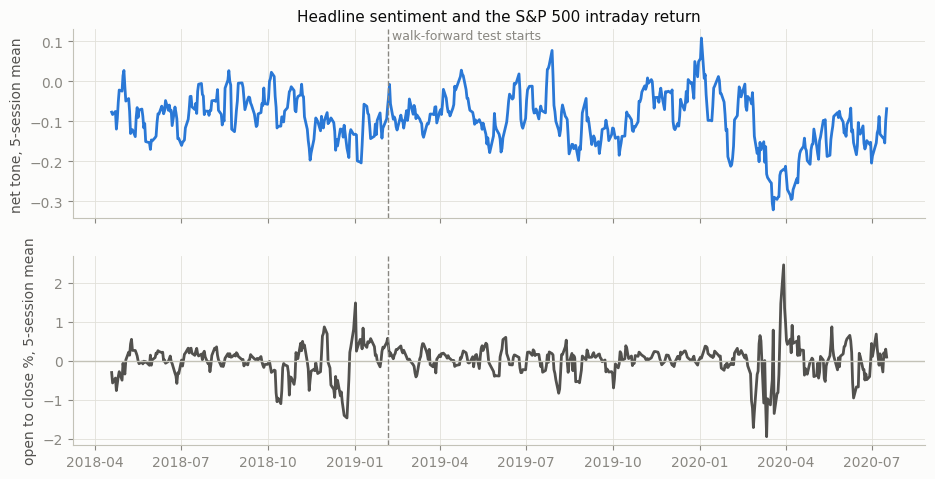

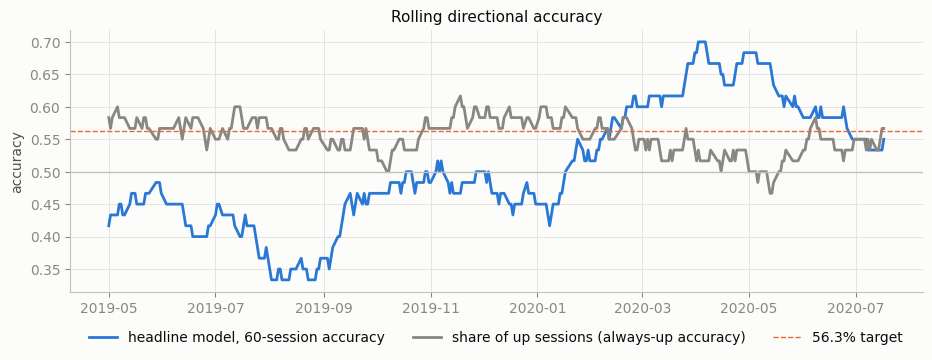

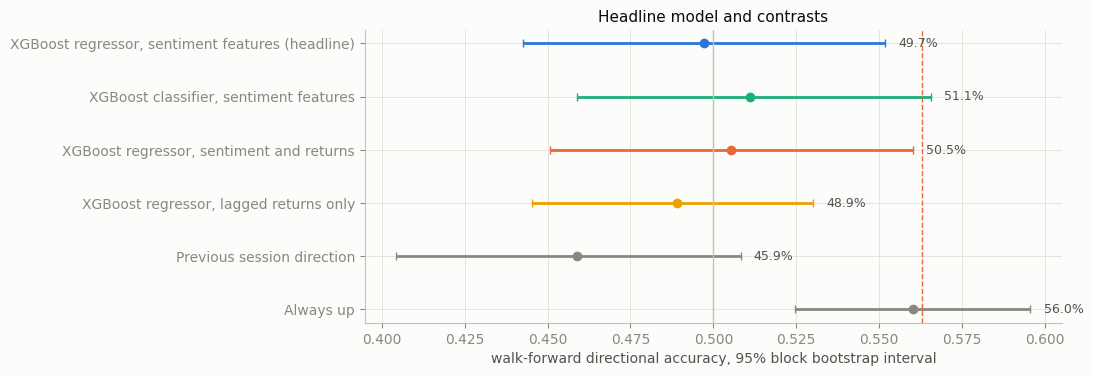

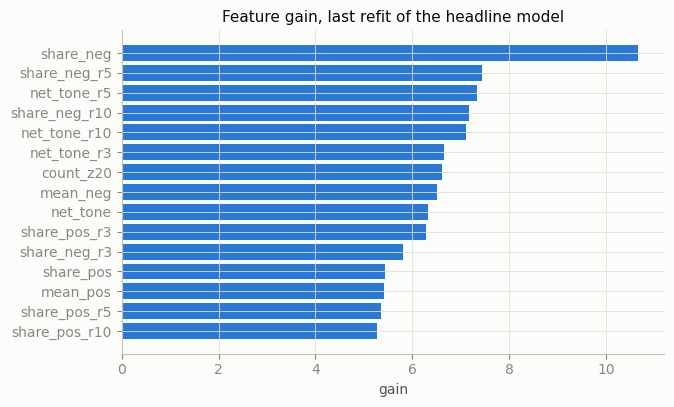

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(11, 5.4), sharex=True)
axes[0].plot(eligible.index, eligible["net_tone"].rolling(5, min_periods=1).mean(), color=SERIES[0])
axes[0].set_ylabel("net tone, 5-session mean")
axes[0].set_title("Headline sentiment and the S&P 500 intraday return")
axes[1].plot(eligible.index, eligible["target"].rolling(5, min_periods=1).mean(), color=INK_2)
axes[1].axhline(0, color=AXIS, linewidth=1)
axes[1].set_ylabel("open to close %, 5-session mean")
for ax in axes:
    ax.axvline(test.index[0], color=MUTED, linestyle="--", linewidth=1)
axes[0].text(test.index[0], axes[0].get_ylim()[1], " walk-forward test starts", color=MUTED, fontsize=9, va="top")
save(fig, "tone_and_returns")
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.plot(rolling.index, rolling.values, color=SERIES[0], label="headline model, 60-session accuracy")
ax.plot(rolling_up.index, rolling_up.values, color=MUTED, label="share of up sessions (always-up accuracy)")
ax.axhline(0.5, color=AXIS, linewidth=1)
ax.axhline(TARGET_ACCURACY, color=SERIES[1], linestyle="--", linewidth=1, label="56.3% target")
ax.set_ylabel("accuracy")
ax.set_title("Rolling directional accuracy")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.1), ncol=3)
save(fig, "rolling_accuracy")
order = ["sentiment", "sentiment_classifier", "sentiment_returns", "returns_only", "previous_direction", "always_up"]
fig, ax = plt.subplots(figsize=(9, 3.8))
for i, name in enumerate(order):
    r = results[name]
    ax.errorbar(r["accuracy"], i, xerr=[[r["accuracy"] - r["low"]], [r["high"] - r["accuracy"]]], fmt="o", color=COLORS[name], capsize=3)
    ax.text(r["high"] + 0.004, i, f"{r['accuracy']:.1%}", va="center", fontsize=9, color=INK_2)
ax.axvline(0.5, color=AXIS, linewidth=1)
ax.axvline(TARGET_ACCURACY, color=SERIES[1], linestyle="--", linewidth=1)
ax.set_yticks(range(len(order)), [NAMES[name] for name in order])
ax.invert_yaxis()
ax.set_xlabel("walk-forward directional accuracy, 95% block bootstrap interval")
ax.set_title("Headline model and contrasts")
save(fig, "contrasts")
top = feature_gain[:15][::-1]
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh([r["feature"] for r in top], [r["gain"] for r in top], color=SERIES[0])
ax.set_xlabel("gain")
ax.set_title("Feature gain, last refit of the headline model")
save(fig, "feature_gain")

**Conclusion.** The tone figure shows net tone falling to about -0.3 in March 2020 while intraday returns swing between -2% and +2.5%, the one stretch where the two series visibly move together. Rolling accuracy stays below 50% through 2019 and rises above the always-up line only from February 2020. In the contrast chart every model's interval straddles 50%, and only always up sits near the target. Feature gain is led by the negative-share features.

## Outputs

Writes the session table with every model's predictions (missing outside the test sessions), the metrics with the benchmark rows, and the tuned settings.

In [12]:
out = eligible[SENTIMENT + ["target"]].copy()
out["in_test"] = out.index.isin(test.index)
for name, pred in predictions.items():
    out[f"score_{name}"] = pd.Series(pred["score"], index=test.index).reindex(out.index)
    out[f"up_{name}"] = pd.Series(pred["up"].astype(float), index=test.index).reindex(out.index)
out.reset_index().to_parquet(OUT / "sessions.parquet", index=False)
counts = {"headlines_scored": len(scores), "headlines_used": len(used), "sessions": len(covered), "eligible": len(eligible), "initial": INITIAL, "test": n}
metrics = {"models": results, "always_up_rate": up_rate, "counts": counts, "test_start": test.index.min().date().isoformat(), "test_end": test.index.max().date().isoformat(),
           "diagnostics": {"half_year": half_year, "covid": covid}, "feature_gain": feature_gain, "benchmarks": benchmarks}
(OUT / "metrics_market.json").write_text(json.dumps(metrics, indent=2, allow_nan=False), encoding="utf-8")
(OUT / "market_params.json").write_text(json.dumps(tuned, indent=2), encoding="utf-8")
print(f"sessions.parquet: {len(out)} rows; metrics_market.json and market_params.json written")
print(elapsed())

sessions.parquet: 566 rows; metrics_market.json and market_params.json written
elapsed 1.1 minutes


**Conclusion.** The session table with every model's predictions, the metrics with the two market benchmark rows (both missed) and the tuned settings are written for notebook 7 and the app.